# Notebook 7 - Assessing the competition outcomes between species 

## A word on why we're not doing a calibration here, but simply an assessment

When starting these calibration notebooks, I wanted to be able to calibrate the competition between tree species. This required us to have "expected calibration outcomes" (meaning references for what the outcomes of the competition should be) for each pair of species. We would compare these expected outcomes to what the model produces, and then use this to tweak the parameters further so that we would obtain the right competition outcomes from the model (in line with the expected outcomes).

However, after a lot of investigation, I abandoned this approach for a simple reason : determining expected competition outcomes for every pair of species is surely impossible with the current data we have. If we want to compute these expected outcomes from empirical growth data (e.g. growth experiments in mixed stands), we quickly find out that a) these studies are quite rare or only concern specific tree species (especially commercial ones), and b) the outcome is influenced by the soil and climate from a different study area (where the growth study was done) than the one we're dealing with here (the study landscape used in Notebook 4 for getting the data for the growth curves, and Notebook 5 for the climate data). In contrast, if we want to compute these outcomes from the traits of our species or other information about them, we quickly run into the problem that many factors are at play that will influence the outcome : the temperature (is one of the species near its range limit ?), the shade tolerance, but also the growth rate differences (e.g. between gymnosperms and angiosperms), and so on.

Because I couldn't find a way to create solid expected outcomes, I abandoned the idea of calibrating the competition between pairs of tree species. Instead, I worked on a method to explore the outcomes that the model produced in order to help us detect if some outcomes seem non-sensical. For example, if a particular tree species overperform all others or underperforms too often, even though it shouldn't necessarily. I also worked on disentangling the effects of the different processes/factors/traits that would influence the outcomes : more on that below. By doing this, we will be able to assess if the parameters calibrated in Notebook 6 (that tried to match the growth curves of Notebook 4) produced satisfying competition outcomes, or if some things should be tweaked. I would have liked to make things automatized here, but things were too complex and I was running out of time. Hence the approach of a more subjective assessment of competition outcomes, but with as much informative visuals as possible.

## Method for the assessment : win rates and disantangling the effect of different factors

In PnET-Succession, I identify three big categories of effects/processes that could influence the outcome of a competition between a pair of tree species:

- The effect of water (through H1, H2, H3, H4)
- The effect of the temperature (through LeafOnMinT, PsnTMin, PsnTOpt, PsnTMax)
- The effect of growth rate and shade tolerance (all the other parameters).

At first, I wanted to separate shade tolerance from the growth rate by equating the shade tolerance of a species with the value of HalfSat; but I realized that the shade tolerance of a tree species is also mixed with its other growth parameters, so that it would be impossible to separate it properly.

With these 3 factors at end, I worked to define a kind of "experimental design" that would allow us to separate the effect of these three factor on the competition, and then represent the effects separately to the user.

It goes like this : for each pair of species, we will do different simulations where we isolate the effect of one or several factors. We isolate the effect of a factor by setting the parameters between the two species to a similar value for the two species (the average of the original value of the parameter for both species). For example, to remove the effect of water on the competition, we set the parameters H1, H2, H3 and H4 at the same value for the two species; the value will be the average for both species (i.e. H1 will be equal to (H1_firstSpecies + H1_secondSpecies)/2 ). By putting the same values for these water parameters to the two species competing, we remove any advantage (or handicap) that one might have compared to the other, relative to water. We can isolate the effect of the temperature in the same way by setting LeafOnMinT, PsnTMin, PsnTOpt and PsnTMax to the same value for both species; and we also can do the same with all of the other species parameters to remove the effect of growth rate and shade tolerance.

This makes it that every simulation we do for a pair of species can have the water effect equalized, the temperature effect equalized, or the growth rate/shade tolerance effect equalized. But we can also equalized two effects, or even three effect at the same time. This gives us 8 unique permutations in total :


| Water parameters | Temperature parameters | Growth rate/shade tolerance parameters |
|:-:|:-:|:-:|
| As usual | As usual | As usual |
| Equalized | As usual | As usual |
| As usual | Equalized | As usual |
| As usual | As usual | Equalized |
| Equalized | Equalized | As usual |
| Equalized | As usual | Equalized |
| As usual | Equalized | Equalized |
| Equalized | Equalized | Equalized |

By running these 8 different permutations for a given pair of species, and computing for each one a measure of "winning" for one of the species (e.g. does this species succeeds at accumulating more biomass than the other at a given timestep), we can then represent the effect of the water, temperature and growth rate/shade tolerance on the outcome of the competition. For that, here is the equation we use :

$Y = \beta_0 + \beta_W\, x_W + \beta_T\, x_T + \beta_{GS}\, x_{GS} + \beta_{WT}\, x_W x_T + \beta_{WGS}\, x_W x_{GS} + \beta_{TGS}\, x_T x_{GS} + \beta_{WTGS}\, x_W x_T x_{GS}$

With $Y$ being the outcome (win rate) of a species at a given timestep in a given simulation; $x_W$, $x_T$ and $x_{GS}$ are the equalization status for the water parameters, temperature parameters and growth/shade parameters respectively. The $\beta$ coefficients are the respective effect of each factor (water, temperature, growth/shade), but also the effect of their interactions.

By running all possible permutations for a pair of species, we can derive the values of the $\beta$ coefficients in the equation, which gives us the strength of the effect of each (water, temperature, growth/shade), using the following equation :

$\beta_j = \frac{1}{8}\sum_{i=1}^{8} \phi_j(i)\, Y_i$

Even better, we can compute the normalized effects that will all sum to 1 using :

$e_W = \frac{\beta_W^2}{\beta_W^2 + \beta_T^2 + \beta_{GS}^2}, \qquad$
$e_T = \frac{\beta_T^2}{\beta_W^2 + \beta_T^2 + \beta_{GS}^2}, \qquad$
$e_R = \frac{\beta_{GS}^2}{\beta_W^2 + \beta_T^2 + \beta_{GS}^2}$

(Note that these equations assume that the interaction between effects are minimal and can be ignored. That's not always the case; but adding the interactions would make things more complex).

We can then use these values on a ternary plot to show the respective effect of water, temperature and growth/shade on the outcome (since they sum to one). See below for an example of the plots.  

One question remains : How to compute the "Winner" of a competition in a pair of species ? For that, we use this equation to compute the outcome $Y$ at a given timestep $c$, but across many replicate cells $k$ (for example, 200 cells) to account for the stochasticity that results from younger cohorts implanting themselves or not:

$Y_c = \frac{1}{N}\sum_{k=1}^{N} \frac{B_1^{(k)} - B_2^{(k)}}{B_1^{(k)} + B_2^{(k)}}, \qquad Y_c \in [-1, 1]$

This $Y$ outcome can therefore range from +1 (species 1 has a bigger biomass than species 2 across all replicate cells at timestep $c$) to -1 (species 2 as a bigger biomass than species 1 across all replicate cells at timestep $c$). 0 Indicates a tie; intermediate values indicate that the species hasn't won across all cells (because of stochasticity).

We're going to compute $Y_{Short term}$ at a timestep of 40 years, and $Y_{Long term}$ at a timestep of 200 years. Both will represent different competitions that will favor trees with different strategies : shade intolerant/fast grower (short term), and shade tolerant/slow grower (long term).

These numbers can be adjusted. In particular, I'm not entirely certain about the timestep value of 200 years for the long term. It might be too much for some species that will simply die; meaning that it's not just growth rate and shade tolerance, but also longevity we're dealing with. Still, we have to start somewhere.

Once we will have computed $Y_{Short term}$ and $Y_{Long term}$ for every combination of species and accross all permutations to isolate the effects of the factors, we can compute the effects ($e_W$, $e_T$, $e_{GS}$) and plot everything.

Below is the code that will do all of this; another section of text below will indicate how to interpret the plots.

:::{warning} "R" is often used to represent "GS" in the code for the functions
I started writing the Python code (using LLMs) for the functions used for this assessment by defining "Water, temperature, and the rest" instead of "Water, temperature and growth rate/shade tolerance". Therefore, the letter R was often used to indicate the effect of growth rate/shade tolerance. I tried to refractor, but you might still find references to "R" in the code. Know that it's for the growth rate/shade tolerance effect.
:::

:::{warning} The following code will take some time to run if you have a lot of species !
The more species you have, the more simulations the following code cell will have to make to account for all combinations. If takes around 10 minutes for 6 species, but will increase exponentially.
:::

[1/105] Done: ABIE.BAL vs ACER.RUB W=False T=True GS=False
[2/105] Done: ABIE.BAL vs ACER.RUB W=True T=False GS=False
[3/105] Done: ABIE.BAL vs ACER.RUB W=False T=False GS=False
[4/105] Done: ABIE.BAL vs ACER.RUB W=False T=False GS=True
[5/105] Done: ABIE.BAL vs ACER.RUB W=False T=True GS=True
[6/105] Done: ABIE.BAL vs PICE.MAR W=False T=False GS=False
[7/105] Done: ABIE.BAL vs ACER.RUB W=True T=True GS=False
[8/105] Done: ABIE.BAL vs ACER.RUB W=True T=False GS=True
[9/105] Done: ABIE.BAL vs PICE.MAR W=True T=False GS=False
[10/105] Done: ABIE.BAL vs PICE.MAR W=False T=False GS=True
[11/105] Done: ABIE.BAL vs PICE.MAR W=False T=True GS=False
[12/105] Done: ABIE.BAL vs PICE.MAR W=True T=False GS=True
[13/105] Done: ABIE.BAL vs PICE.MAR W=True T=True GS=False
[14/105] Done: ABIE.BAL vs PICE.MAR W=False T=True GS=True
[15/105] Done: ABIE.BAL vs ACER.SAH W=False T=False GS=False
[16/105] Done: ABIE.BAL vs ACER.SAH W=True T=False GS=False
[17/105] Done: ABIE.BAL vs ACER.SAH W=False T=True G

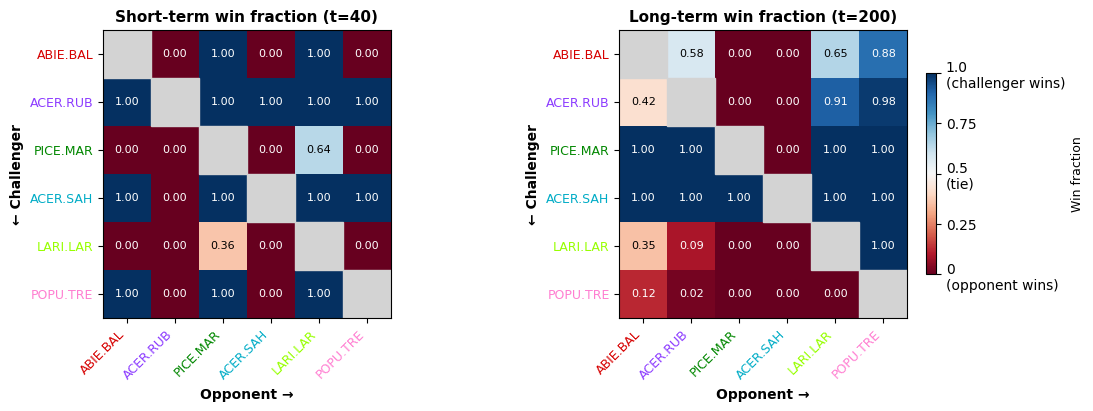

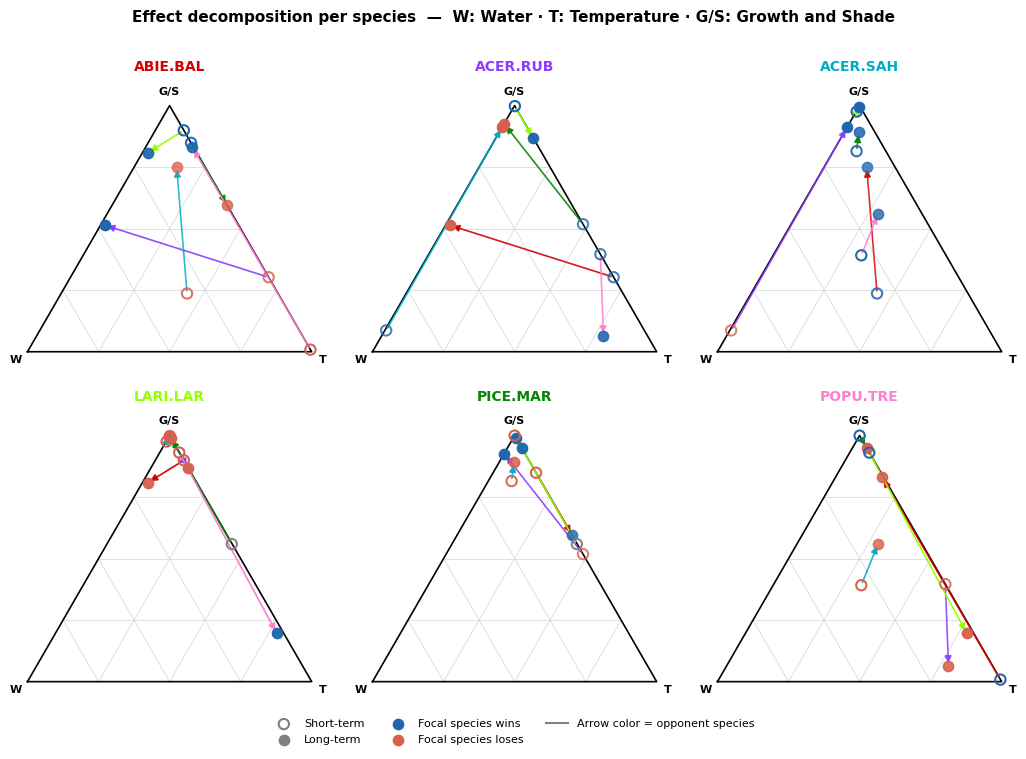

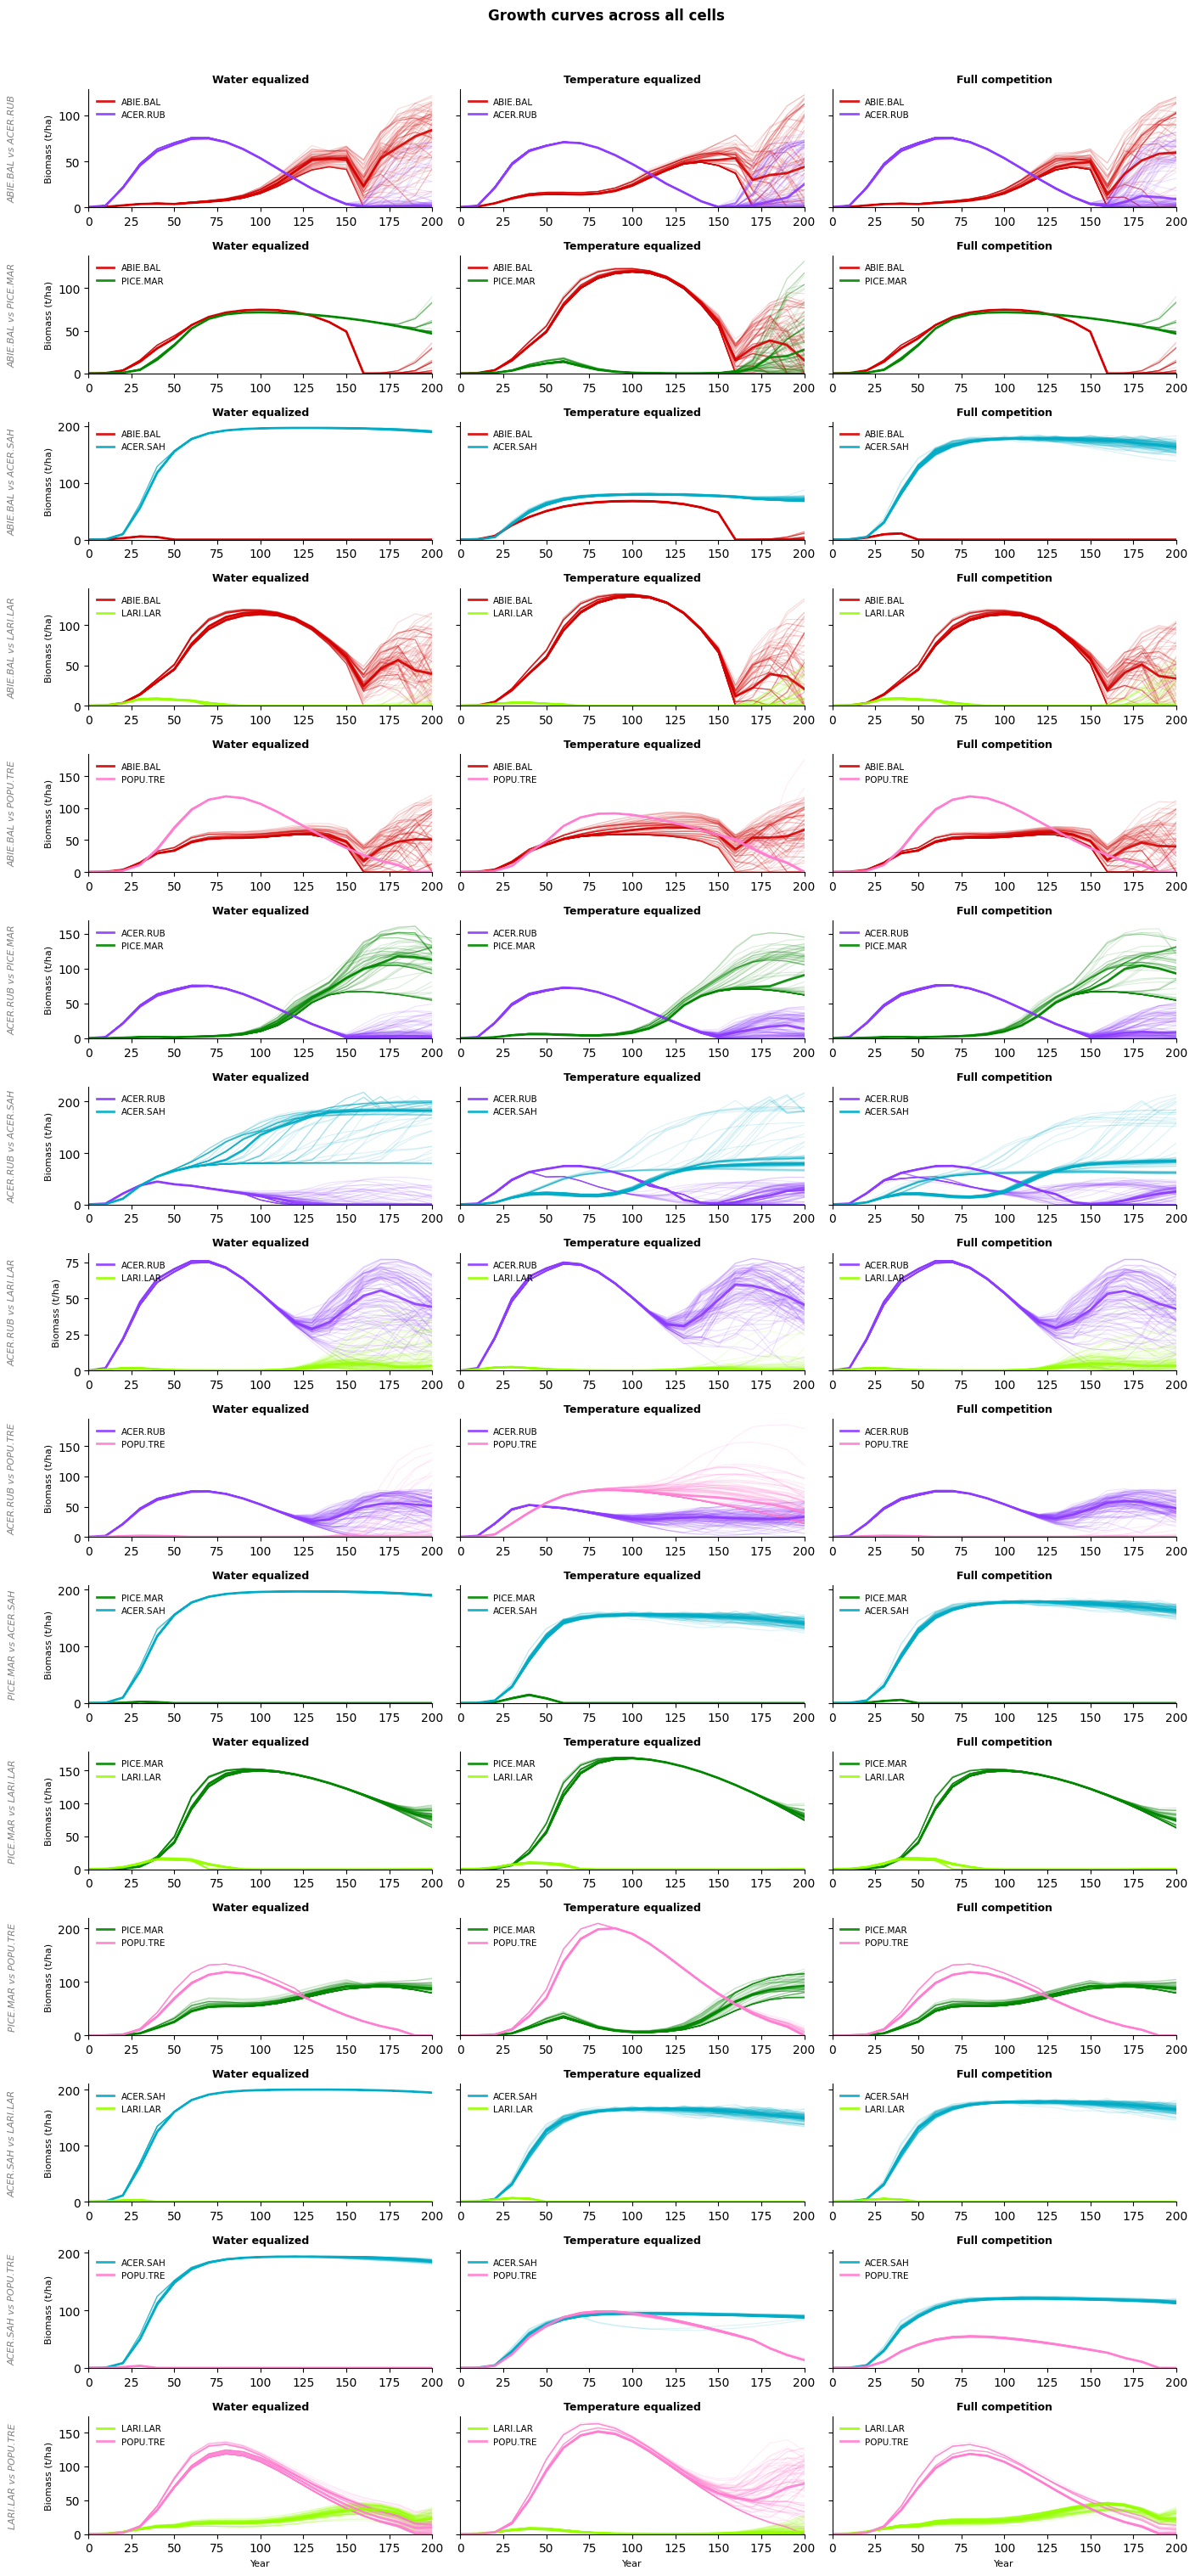

In [2]:
from functionsForCalibration import *

# Load the list of species using the species names dictionnary defined in Notebook 3.
with open('./SpeciesParametersSets/speciesNamesDictionnary.json', 'r') as file: speciesDict = json.load(file)

# ── 1. Run all simulations ─────────────────────────────────────────────────────
species_list = list(speciesDict.keys())  # your list

 # Use more workers (n_workers) to launch sims in parallel to speed up things
all_pairs = run_all_pairs(species_list, n_workers = 4,
                          dict_core_species = json.load(open('./SpeciesParametersSets/Calibrated_SubSubPhase1.4/coreSpeciesParameters.json')),
                          dict_pnet_species = json.load(open('./SpeciesParametersSets/Calibrated_SubSubPhase1.4/PnETSpeciesParameters.json')),
                          dict_pnet_generic= json.load(open('./SpeciesParametersSets/Calibrated_SubSubPhase1.4/genericParameters.json')),
                         climate = "mild",
                         soil = "CLAY")

# ── 2. Compute effect decompositions ──────────────────────────────────────────
decomps_short, decomps_long = [], []
for pair in all_pairs:
    d_short, d_long = compute_effects(pair)
    decomps_short.append(d_short)
    decomps_long.append(d_long)

# ── 3. Plots ───────────────────────────────────────────────────────────────────
speciesColorDict = make_species_colors(species_list)

fig_matrices = plot_win_matrices(all_pairs, species_list, speciesColorDict)
fig_ternary  = plot_ternary_effects(decomps_short, decomps_long, speciesColorDict)
fig_curves   = plot_growth_curves_competition(all_pairs, speciesColorDict)

### Interpreting the plots and making fixes

Now that you have the plots showing the competition outcomes from your current PnET parameters, let's take a look at them.

The first figure contains the win matrices plots: they show you how much one species tended to win (across the replicate cells) against another, **in a simulation were none of the parameters were equalized**. On this plot, we don't deal with the effect of water, temperature, and growth/shade. It's just a representation of what you should expect in your simulations if you keep your parameters as they are.

The second figure contains the ternary plots: they show you a lot of information. There is one plot per species. On each plot, you'll see hollow circles and full circles. The hollow circle represent the short-term outcome of a competition, and the full the long-term outcome. If the circle is blue, the species won. If the circle is red, it lost. There is an arrow between each pair of hollow/full circles; the color of the arrow represents the species against which the species of the given plot was competing against. Therefore, these ternary plots will give you a quick glance of a) is the species often a looser or a winner (blue versus red circles); b) if the outcomes are rather influenced by water or temperatures or growth/shade;  and c) if certain species pairs have their outcome specifically influenced by one of the three factors.

The third figure simply shows the growth curves (across all 200 replicate cells, superpose) for all species pair, with curve for the permutation with the water parameter equalized; the temperature parameters equalized; and no equalization (full competition). I thought this would be best to have a better glimpse of how the effects manifest on the growth curves themselves, and if they validate the information of the previous figures.

As such, there is a lot of information on these figures. Especially if you have a good number of species (since this will make for more plots).

Here is how I recommend to read them. Your objective is to find out:

- If you have species that win too often on the short term and/or long term (e.g. almost all competitions result in a win)
- If you have species that loose too often on the short term and/or long term (e.g. almost all competitions result in a loss)
- If species near the limit of their thermal range (for the climate of your study area, as defined in Notebook 5) see their competition outcomes often influenced by temperature
- If species with very low drought or waterlogging tolerance are 

So, in order :

- Look at the first figure, and try to identify species that win or loose too often. Be certain to have an explaination for each, or go back to the previous notebook to recalibrate. You might need to adjust the initial parameters (notebook 3), the targets (notebook 4), or the algorithms (notebook 6 and `functionsForCalibration.py`).
    - In my case, the first time I assessed the competition of the 6 species calibrated here, I noticed that one in particular (POPU.TRE) was not competing well, without any good reason. I realized that it wasn't growing fast enough in its first years and was out-competed. I went to adjust the functions used in Notebook 6 to correct this.
- Identify the tree species that are near their thermal range; you can use data from [Dendoncker et al. 2026](https://www.sciencedirect.com/science/article/pii/S2666900526000079) to help you for North american species. Then, look on figure 2 if these species are affected by the temperature. You can re-launch the simulations with a different climate file (see argument `climate` of `run_all_pairs()`) to see if this changes your outcomes as you think.
- Identify the tree species with a quite low drought tolerance, or a high waterlogging tolerance compared to other species, or vice versa. Launch the simulations on a sandy soil (`SAND`) or with a climate that has less precipitations (see argument `climate` of `run_all_pairs()`), and see if the water becomes an important factor in the competition outcomes for these species. If that's not the case, your climate file might give too much or too little water, keeping water in the soil so that it will not influence things. The `SILO` soil, used in Notebook 6, is considered by the creators of PnET-Succession as a soil type that tends to keep the "best" amount of water. If you use it, you might not see water effects that much. In contrast, the `CLAY` soil is supposed to produce waterlogging more easily.


:::{tip} Document your changes iteratively in this notebook !
As you assess the competition between your tree species, validate them, or keep changing things to obtain outcomes you consider more realistic, remember to document your thought process here for transparency and replicability. Why does such and such outcome seems OK to you ? You might not be able to assess them all in detail as there will be too many, but addressing the most important or surprising ones will be essential to communicate to your readers or reviewers.
:::

:::{tip} Keep these figures for your supplementary materials !
You can join these figures as a supplementary material for an article that you will make based on the parameter you're making. Or all of these notebooks, really. This will ensure a lot of transparency to your readers and viewers.
:::

:::{tip} Check [Burns and Honkala (1990)](https://www.srs.fs.usda.gov/pubs/misc/ag_654/table_of_contents.htm) for a lot of information about the competition between species in North America !
The sylviculture guides of [Burns and Honkala (1990)](https://www.srs.fs.usda.gov/pubs/misc/ag_654/table_of_contents.htm) is a great source of information about species traits, but also competition between species. I strongly advise that you use it to explore if what you're getting out of your competition outcomes makes sense.
:::

:::{note} The conflict between your growth curves (Notebook 4) and other information about the competition of tree species and the model.
In Notebook 6, we have calibrated the parameters of PnET-Succession so that the growth curves of your tree species generated by the model match, as much as possible, those that you obtained in Notebook 4.

As such, when we assess (and potentially correct) the competition between tree species here, we are dealing with three conflicting processes or sources of information :

- Your growth curves (Notebook 4)
- Other information about the competition between your tree species ([Burns and Honkala (1990)](https://www.srs.fs.usda.gov/pubs/misc/ag_654/table_of_contents.htm), expert opinion, your own knowledge, other forestry or forest ecology sources or books, etc.)
- What the model is capable to generate

For example : your growth curves from notebook 4 might say that trees of species A grows faster than tree of species B at the beginning of their lives. But that might clash with other informations you have, which says that trees of species B should be growing faster and outcompeting species A. Meanwhile, PnET-Succession might not be able to make the age cohorts of species B grow fast enough to othercome the age cohorts of species A, without tweaking the parameters of species B far away from their empirical bounds.

While I tried to automatize and script everything as much as possible, this dissonance between different sources of information and what the model is actually capable of doing is a mess that I haven't found how to generalize and automatize. As such, you will have to take decisions here, and try to find the best way forward. Your growth curves have limitations because you're trying to estimate them in ideal conditions (which often don't exist in real life); but the opinion of experts/forestry handbooks also have limitations as they make generalities at the scale of countries or continents, while you're looking at things more locally. Try to find a consensus between these two sources (growth curves and other information about competition), and then try to approach it as best you can in the model. If you can't, note it as a limitation of the model, and move on; things are not perfect, and that's OK !
:::

## Documenting the changes for this calibration

### First assessment

- LARI.LAR looses almost all of its competitions. It seems to be a tree rather adapted to very wet soils, or to quite cold environments. As such, I expect it to win more in colder climates and on wetter soils. But I'm having a lot of trouble making soils that are really wetter in LANDIS-I; even using `soil = "CLAY"` is not enough to change things much using previous explorations of the model. I've contacted Eric Gustafson, Brian Sturtevant and Brian Miranda about it. The problem is that even if the soil is supposed to have more water, the pressure head remains similar between soils, which prevents a true waterlogging from taking place. I'll keep things as they are for now for this species, as I feel like I'm hitting a limit of the model.
    - From [Burns and Honkala (1990)](https://www.srs.fs.usda.gov/pubs/misc/ag_654/volume_1/larix/laricina.htm) : *With abundant light, tamarack is one of the fastest growing conifers on uplands in the boreal (including Alaska) and northern forest regions; on peatlands it outgrows any other native conifer (6,12,50)*.
    - More globally, the text from [Burns and Honkala (1990)](https://www.srs.fs.usda.gov/pubs/misc/ag_654/volume_1/larix/laricina.htm) paints the picture of a tree species that is relatively fast growing and very shade intolerant, but who out-compete others mostly on soils that are quite wet. As such, what we should reproduce in LANDIS-II is a tree with an initial growth rate that is relatively high, and which will slow down after a while because of self-competition (through shade). But it will truly shine thanks to its increased cold temperature and wetland tolerance.
    - But trying to change the speed of its initial growth curve has been inconclusive, and leads to issues. As such, I'll keep it as it is.
- ACER.SAH wins a lot on the long term.
    - It is influenced by temperature, which is good; it should be near the edge of its distribution.
    - It has a very high tolerance to shade; as such, its win on the long-term makes a lot of sense.
    - Nothing more to do here, seems OK.
    - However, it seems to win a lot on short-term competitions too. This is surely due to its very high growth peak coming from Notebook 6 compared to other species. [Burns and Honkala (1990)](https://www.srs.fs.usda.gov/pubs/misc/ag_654/volume_2/acer/saccharum.htm) state : *Early growth of sugar maple is slow, partly because it regenerates under heavy shade*. As such, we should reduce its early growth.
- PICE.MAR wins a lot on the long term.
    - According to [Burns and Honkala (1990)](https://www.srs.fs.usda.gov/pubs/misc/ag_654/volume_1/picea/mariana.htm), PICE.MAR should be outcompeted on the short term by others species such as ABIE.BAL, which is what we do see. However, the authors seem to say that it can escape competition on the longer term, which is what we see. They write *black spruce is often overtopped by quaking aspen, paper birch, tamarack, black ash, or red maple for many years before it becomes dominant*. I consider that what we have so far is quite good enough, especially once we will have increased the early growth of POPU.TRE and LARI.LAR.
 
**To-do list :**

- [ ] Check the growth peak height and age of ACER.SAH from Notebook 4, and see how much slower it should grow to compete less with other species. Tweak the parameters so that it does.

### How to tweak your parameters to solve competition issues

The main goal we have in tweaking the competition is to change three things of the species that are not competing properly (in order of priority) :

- The shape of the curve towards the growth peak (fast, and then slower; or slower, and then faster)
- The growth peak age
- The growth peak height

Most often, the peak age and peak height are not the issue; it's the shape of the growth curve towards them that we want to change.

As I'm running out of time, I'm proposing to do things by hand here. Below is a code cell you can use to tweak the parameters manually until you get something satisfying. Another code cell afterward will allow you to save the parameters you have defined in a new set.

#### Changing the shape of the curve towards the growth peak

This is what we will most often need : make sure that we accelerate or decelerate the initial growth of some species that do not compete properly (undercompete or overcompete), while keep the age and height of their biomass peak the same.

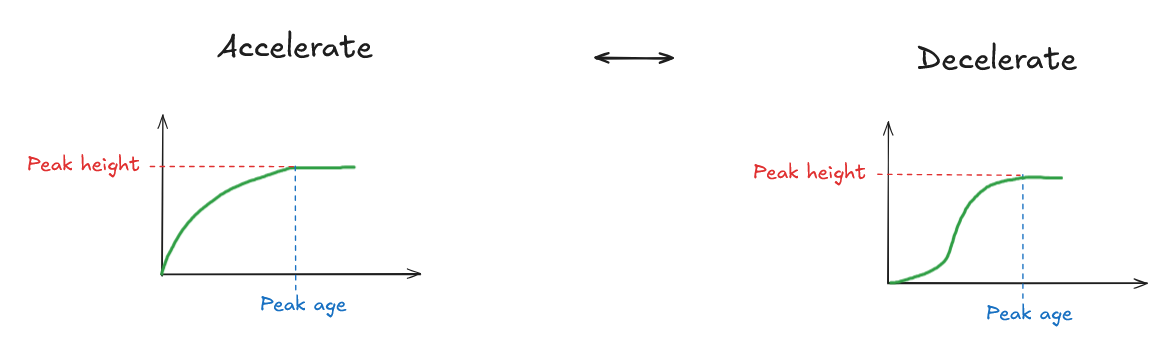

The problem is : this is what's most complicated to do in PnET-Succession in my experience, as there is no proper way (currently) to separatly affect the growth speed in the first years of the species, and the growth speed in its later year. But we need this distinction if we want to change the shape of the curve without affecting the peak age and peak height.

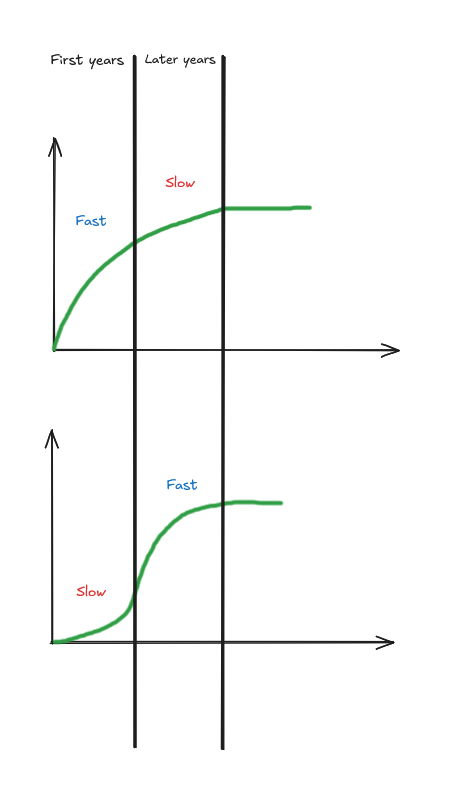


:::{error}
I've worked hard to find a solution to this; I didn't find any. Even by using MaxFracFol/FracFolShape and MaxFolN/FolNShape, I'm not able to influence precisely the beginning of the curve. I've written this in Notebook 100 (future improvements).

**Instead, I recommend you directly change the peak age, even if you get something a bit different that what the growth curves in Notebook 4 have predicted**. See below.
:::

#### Changing the peak age

If changing the shape of the curve is not possible (see above), or if external information for your species tell you that the peak age is quite wrong, you can easily re-calibrate the peak age of the species using the functions of Notebook 6.

:::{warning} Be careful about the `disableLongevity` argument
If you re-use the function `calibrate_subphase_1_2()` of Notebook 6 as I do in the code cell below, be certain to indicate the argument `disableLongevity` as `False`. This argument is on by default to remove the effect on longevity during the first subphases of the calibration in Notebook 6; here, as senescence has already been calibrated, we want to keep it. If you don't, the function will start from the wrong point.
:::

The code cell bellow allows you to precise edited peak ages for several tree species (through a Python dictionnary). The code will then re-calibrate each species using the function `calibrate_subphase_1_2()`, and then re-calibrate senescence (phase 1.4 in Notebook 6) via `calibrate_senescence()`. A shift in just 5-10 years in the peak age can be enough. What you should look at is the resulting graph were the growth curve of each tree species is superposed (made by the same code cell below); if your species grows quicker than others, it should compete better. Try to make sure that it grows a bit quicker than 1-2 species for which you have good evidence that it should compete well against them (for example, based on the information of [Burns and Honkala (1990)](https://www.srs.fs.usda.gov/pubs/misc/ag_654/table_of_contents.htm)).


#### Changing the peak height

Most likely not needed, as competition in PnET-Succession is mostly a result of who dominates the canopy/grows the quickest at first. But to do this, you can use the functions of Notebook 6 again.


### The changes done here

:::{warning} These changes are ultimately arbitrary
There is not perfect measure of how much to adjust your tree species's growth here. It's all in trying to make sure that their competition is "more realistic", which is again very subjective. The goal in this notebook is that you write your assumptions clearly so that your methodology remains transparent, even though such decisions are ultimately arbitrary.
:::

- `ACER.SAH` : Decelerating its peak by 10 years.
    - Its current growth curve is quite ahead of others, so we slow it down a bit.

New target age : 100.99162 for ACER.SAH
Subphase 1.2 — Species: ACER.SAH

[Baseline] Running baseline simulation...
Launching LANDIS-II simulation with command : /bin/bash -c "cd /tmp/monocultureCalibrationPnET/ && dotnet $LANDIS_CONSOLE scenario.txt"
The LANDIS-II simulation has finished properly!
  Baseline peak time    : 82.5 yr
  Baseline max LAI      : 4.9044
  Baseline peak biomass : 17579.00 g/m²

--- Phase A: Adjusting MaxFracFol (FracFolShape coupled) ---
Launching LANDIS-II simulation with command : /bin/bash -c "cd /tmp/monocultureCalibrationPnET/ && dotnet $LANDIS_CONSOLE scenario.txt"
The LANDIS-II simulation has finished properly!
  [A-  1] MaxFracFol=0.0037  FracFolShape=8.0000 | PeakTime=277.5 yr | MaxLAI=0.2052
Launching LANDIS-II simulation with command : /bin/bash -c "cd /tmp/monocultureCalibrationPnET/ && dotnet $LANDIS_CONSOLE scenario.txt"
The LANDIS-II simulation has finished properly!
  [A-  2] MaxFracFol=0.0137  FracFolShape=8.0000 | PeakTime=106.5 yr | MaxLAI=

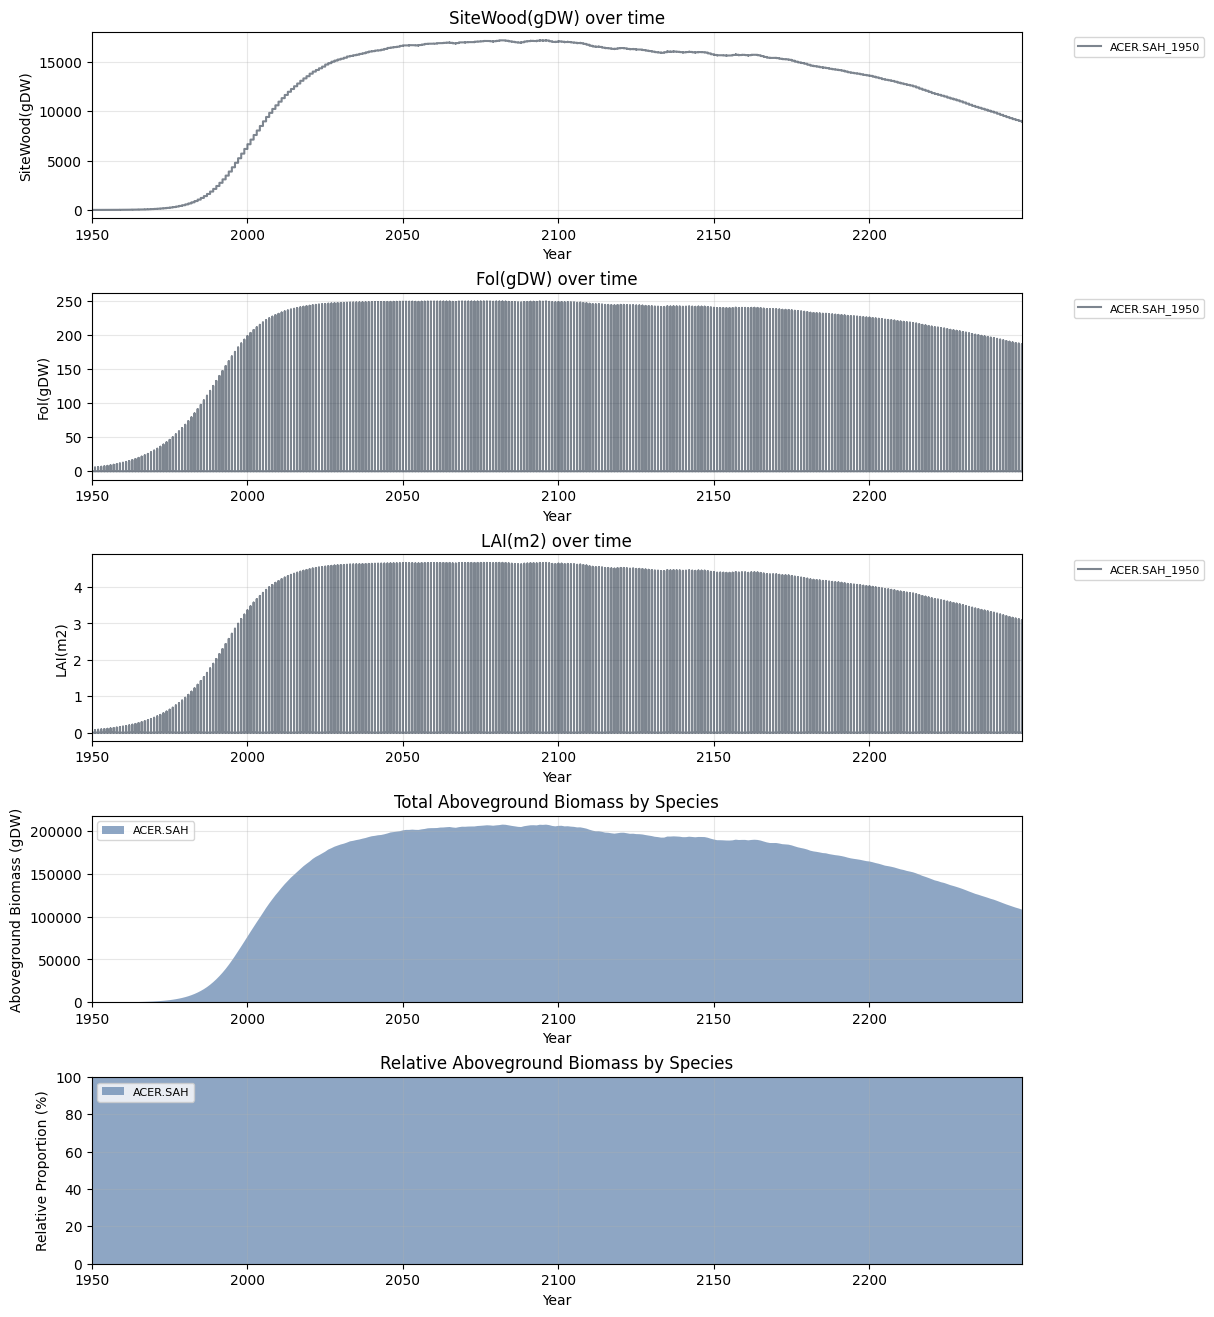

CALIBRATION RESULTS — Subphase 1.2
  MaxFracFol        : 0.016164
  FracFolShape      : 8.000000
  FrActWd           : 0.000035
  FolN              : 2.400000
  FracFol           : 0.024561
  TOWood            : 0.030180
  TORoot            : 0.030300

  Final peak time   : 96.5 yr  (target: 101.0 ± 5.0 yr)  ✓ Still within tolerance
  Final peak biomass: 17100.00 g/m²  (target: 17794.78 ± 5%)  ✓ OK

  ✓ Subphase 1.2 calibration complete.

Subphase 1.4 – Senescence calibration for ACER.SAH
  Target typical mortality (initiation of decline) : 300.0 years
  Target maximum mortality (time of death)         : 400.0 years
  Target peak biomass                              : 17794.78 g/m²
  Tolerance                                        : ±3 years

  [Init] PsnAgeRed = 3.9572
  [Init] Longevity  = 483.77 years
  [Init] Analytical initiation of decline = 270.36 years (target: 300.0)

  [Iter 1] PsnAgeRed = 3.9572 | Longevity = 483.77
Launching LANDIS-II simulation with command : /bin/bash -c

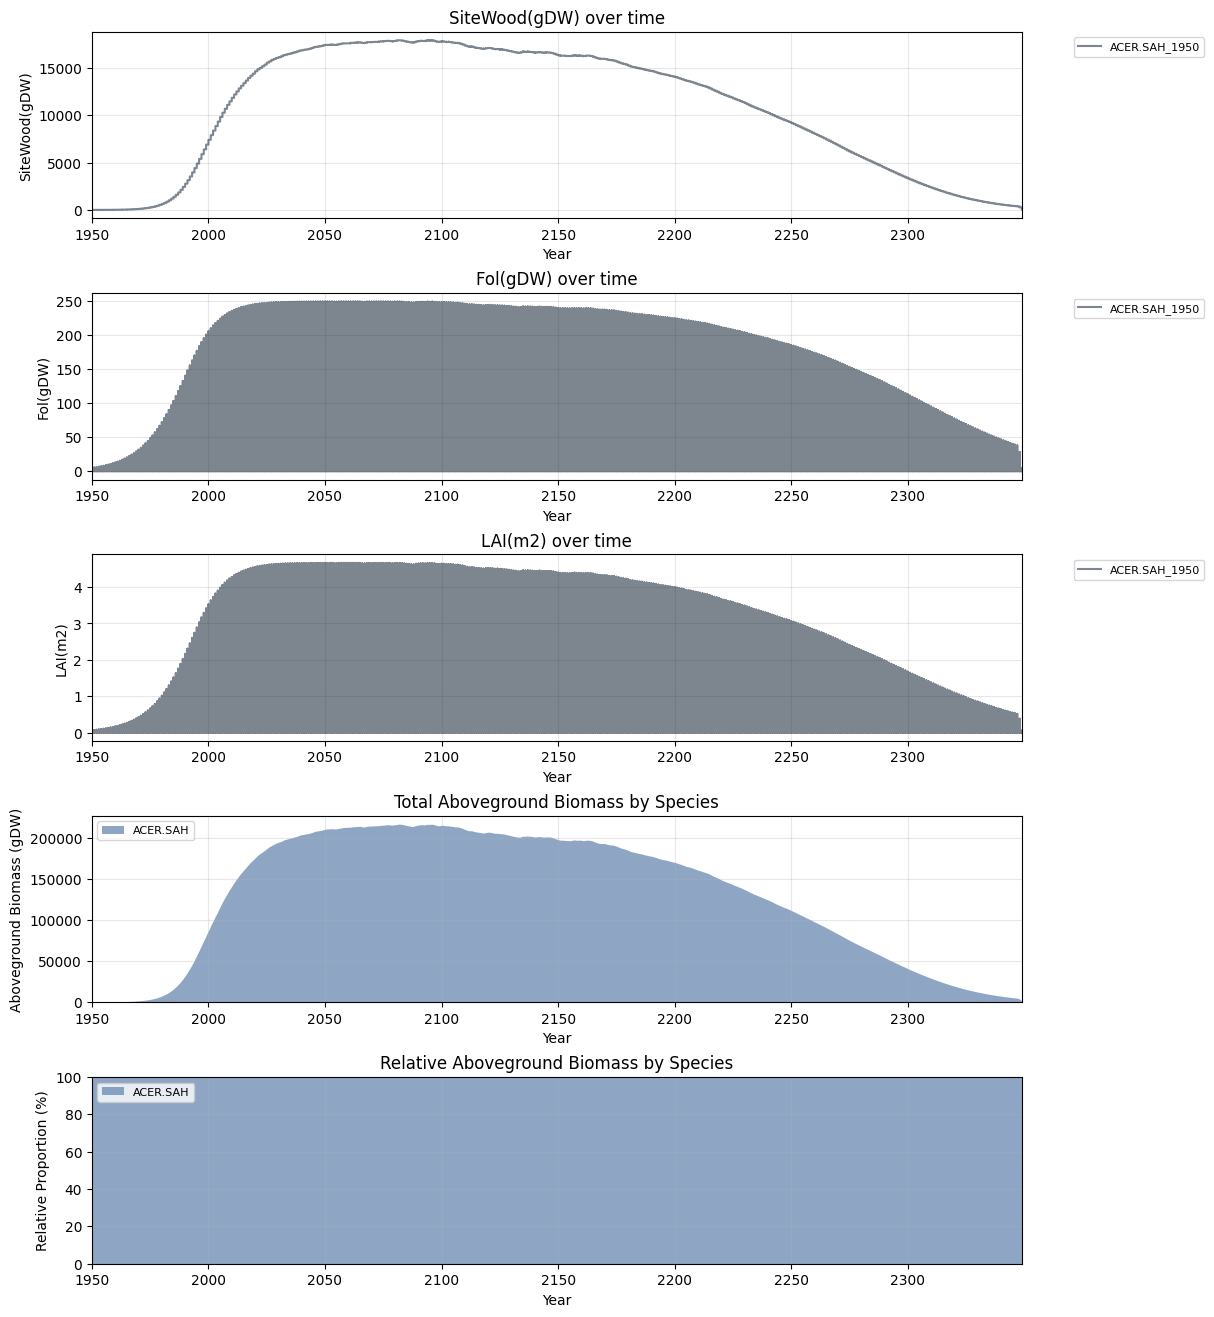

Launching LANDIS-II simulation with command : /bin/bash -c "cd /tmp/monocultureCalibrationPnET/ && dotnet $LANDIS_CONSOLE scenario.txt"
The LANDIS-II simulation has finished properly!


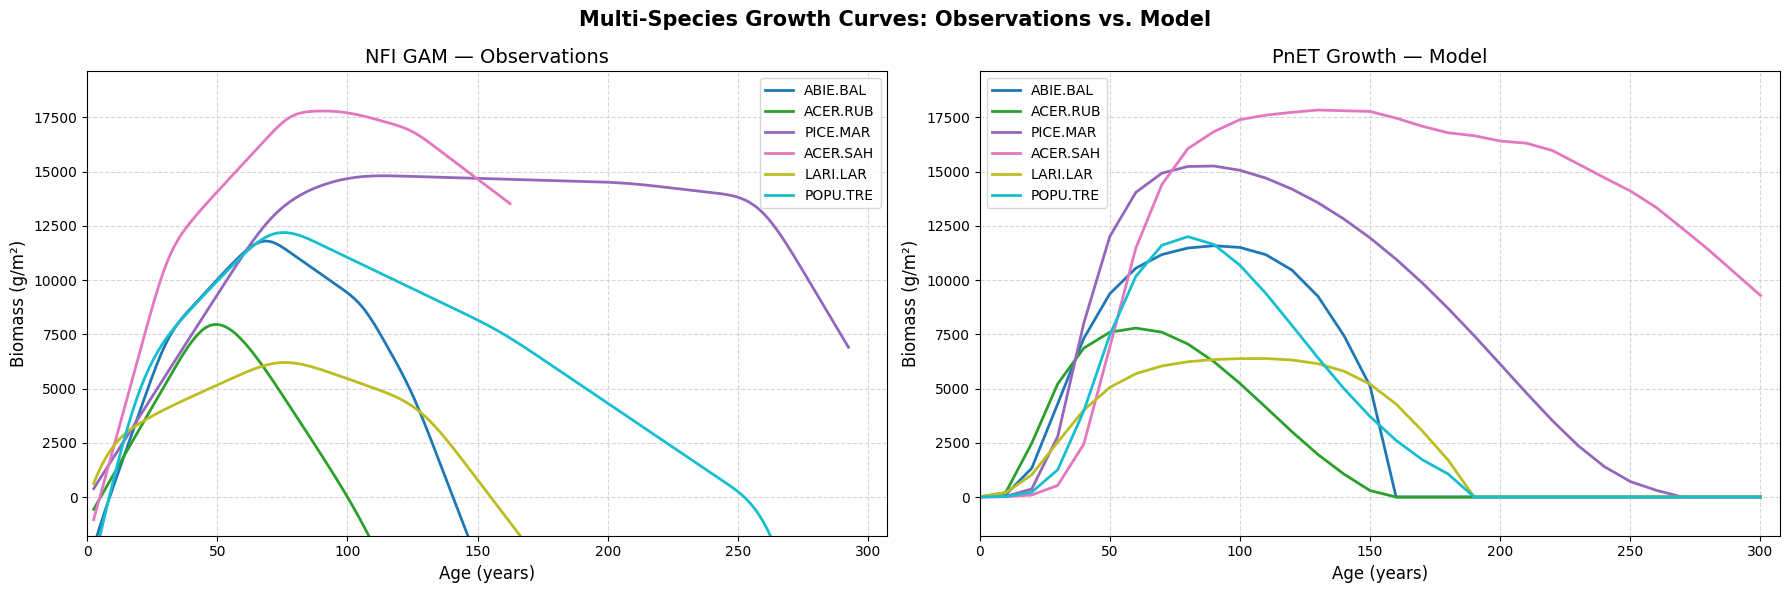

In [11]:
from functionsForCalibration import *
import copy

with open('./SpeciesParametersSets/speciesNamesDictionnary.json', 'r') as file: speciesDict = json.load(file)
with open('./ReferencesAndData/Functional Traits/SpeciesTolerancesAndTargets.json', 'r') as file: SpeciesTolerancesAndTargets = json.load(file)

dictOfCoreSpeciesParameters = json.load(open('./SpeciesParametersSets/Calibrated_SubSubPhase1.4/coreSpeciesParameters.json'))
dictOfPnETSpeciesParameters = json.load(open('./SpeciesParametersSets/Calibrated_SubSubPhase1.4/PnETSpeciesParameters.json'))
dictOfPnETGenericParameters = json.load(open('./SpeciesParametersSets/Calibrated_SubSubPhase1.4/genericParameters.json'))

peakAgeEditDictionnary = { 
"ACER.SAH":SpeciesTolerancesAndTargets["ACER.SAH"]["Peak_age"] + 10
}

# We re-calibrate the peak age
resultDict = {}
for speciesToEdit in peakAgeEditDictionnary.keys():
    
    newTargetAge = peakAgeEditDictionnary[speciesToEdit]
    print(f"New target age : {newTargetAge} for {speciesToEdit}")
    
    resultDict[speciesToEdit] = calibrate_subphase_1_2(
        species = speciesToEdit,
        target_peak_time = newTargetAge,   # years (from NFI data)
        target_peak_biomass = SpeciesTolerancesAndTargets[speciesToEdit]["Peak_Biomass"],
        target_LAI = SpeciesTolerancesAndTargets[speciesToEdit]["Maximum LAI target"],
        dictOfBounds = json.load(open("./SpeciesParametersSets/SpeciesParameterBounds.json")),
        dict_core_species = json.load(open('./SpeciesParametersSets/Calibrated_SubSubPhase1.4/coreSpeciesParameters.json')),
        dict_pnet_species = json.load(open('./SpeciesParametersSets/Calibrated_SubSubPhase1.4/PnETSpeciesParameters.json')),
        dict_pnet_generic = json.load(open('./SpeciesParametersSets/Calibrated_SubSubPhase1.4/genericParameters.json')),
        duration = 300,
        climate = "mild",
        soil = "SILO",
        disableLongevity = False, # Don't forget to keep that at False ! By default, it's True.
        peak_time_tolerance = 5 # Lowered so that we can adjust the peak time with more precision than in Notebook 6.
    )
    
# We set the new parameter values with this re-calibration
for speciesToEdit in resultDict:
    dictOfPnETSpeciesParameters["PnETSpeciesParameters"][speciesToEdit]["MaxFracFol"] = resultDict[speciesToEdit]["MaxFracFol"]
    dictOfPnETSpeciesParameters["PnETSpeciesParameters"][speciesToEdit]["FracFolShape"] = resultDict[speciesToEdit]["FracFolShape"]
    dictOfPnETSpeciesParameters["PnETSpeciesParameters"][speciesToEdit]["FrActWd"] = resultDict[speciesToEdit]["FrActWd"]
    dictOfPnETSpeciesParameters["PnETSpeciesParameters"][speciesToEdit]["FracFol"] = resultDict[speciesToEdit]["FracFol"]
    dictOfPnETSpeciesParameters["PnETSpeciesParameters"][speciesToEdit]["TOWood"] = resultDict[speciesToEdit]["TOWood"]
    dictOfPnETSpeciesParameters["PnETSpeciesParameters"][speciesToEdit]["TORoot"] = resultDict[speciesToEdit]["TORoot"]
    dictOfPnETSpeciesParameters["PnETSpeciesParameters"][speciesToEdit]["FolN"] = resultDict[speciesToEdit]["FolN"]

# We re-calibrate the senescence after that
resultDict = {}
for speciesToEdit in peakAgeEditDictionnary:
    resultDict[speciesToEdit] = calibrate_senescence(
        species = speciesToEdit,
        typical_mortality = SpeciesTolerancesAndTargets[speciesToEdit]["Longevity"], # TYPMORT from Loehle
        maximum_mortality = SpeciesTolerancesAndTargets[speciesToEdit]["Maximum longevity"], # MAXMORT from Loehle
        target_peak_biomass = SpeciesTolerancesAndTargets[speciesToEdit]["Peak_Biomass"],
        dictOfBounds = json.load(open("./SpeciesParametersSets/SpeciesParameterBounds.json")),
        dict_core_species=copy.deepcopy(dictOfCoreSpeciesParameters), 
        dict_pnet_species=copy.deepcopy(dictOfPnETSpeciesParameters),
        dict_pnet_generic=copy.deepcopy(dictOfPnETGenericParameters),
        tolerance=3,
        max_iterations=50,
        simulation_duration=500,
        climate="mild",
        soil="SILO")

# We set the new parameter values with this re-calibration
for speciesToEdit in resultDict:
    for parameter in ["PsnAgeRed", "TOWood", "TORoot"]:
        dictOfPnETSpeciesParameters["PnETSpeciesParameters"][speciesToEdit][parameter] = resultDict[speciesToEdit][parameter]
    dictOfCoreSpeciesParameters[speciesToEdit]["Longevity"] = str(resultDict[speciesToEdit]["Longevity"])
if "PsnAgeRed" in dictOfPnETGenericParameters.keys(): del dictOfPnETGenericParameters["PsnAgeRed"]

for speciesToEdit in peakAgeEditDictionnary:
    calibrationSimulationMonoculture(duration = 300,
                                            climate = "mild",
                                            soil = "SILO",
                                            speciesToSimulate = speciesToEdit,
                                            dict_core_species = copy.deepcopy(dictOfCoreSpeciesParameters),
                                            dict_pnet_species = copy.deepcopy(dictOfPnETSpeciesParameters),
                                            dict_pnet_generic = copy.deepcopy(dictOfPnETGenericParameters),
                                            plotResults = False,
                                            plotAdjustedParameters = False,
                                            saveGrowthCurvePath = "./SpeciesParametersSets/Checkup_Competition/" + str(speciesToEdit) + "_Growth_PnET.csv")

# Displaying growth curves together
listOfGrowthPnETCheckups = list()
listOfGrowthCurvesGAMS = list()
for speciesCode in speciesDict:
    # We put the path of the NFI curves and the final growth curves in lists for the last plot where we will put all of the curves.
    listOfGrowthCurvesGAMS.append("./ReferencesAndData/Growth Curves Predictions/" + str(speciesDict[speciesCode]) + "_gam_predictions.csv")
    if speciesCode in peakAgeEditDictionnary.keys():
        listOfGrowthPnETCheckups.append("./SpeciesParametersSets/Checkup_Competition/" + str(speciesCode) + "_Growth_PnET.csv")
    else: # If we haven't modified it, we just re-use existing growth curves made at the end of notebook 6
        listOfGrowthPnETCheckups.append("./SpeciesParametersSets/Checkup_Step1/" + str(speciesCode) + "_Growth_PnET.csv")

# We then use another custom function to plot all of the growth curves of the tree species next to each other.
plot_multispecies_growth_curves(
    listOfGrowthCurvesGAMS,
    listOfGrowthPnETCheckups,
    list(speciesDict.keys()))

# We save a new set of parameters
if os.path.exists("./SpeciesParametersSets/Calibrated_CompetitionTweaks"):
    shutil.rmtree("./SpeciesParametersSets/Calibrated_CompetitionTweaks")
os.mkdir("./SpeciesParametersSets/Calibrated_CompetitionTweaks")

with open("./SpeciesParametersSets/Calibrated_CompetitionTweaks/coreSpeciesParameters.json", "w") as f: json.dump(dictOfCoreSpeciesParameters, f)
with open("./SpeciesParametersSets/Calibrated_CompetitionTweaks/PnETSpeciesParameters.json", "w") as f: json.dump(dictOfPnETSpeciesParameters, f)
with open("./SpeciesParametersSets/Calibrated_CompetitionTweaks/genericParameters.json", "w") as f: json.dump(dictOfPnETGenericParameters, f)

## Second assessment

Now that we have edited the peak age of `LARI.LAR` and `ACER.SAH`, let's assess the competition between species again.

[1/105] Done: ABIE.BAL vs ACER.RUB W=False T=True GS=False
[2/105] Done: ABIE.BAL vs ACER.RUB W=True T=False GS=False
[3/105] Done: ABIE.BAL vs ACER.RUB W=False T=False GS=False
[4/105] Done: ABIE.BAL vs ACER.RUB W=False T=False GS=True
[5/105] Done: ABIE.BAL vs ACER.RUB W=False T=True GS=True
[6/105] Done: ABIE.BAL vs PICE.MAR W=False T=False GS=False
[7/105] Done: ABIE.BAL vs ACER.RUB W=True T=True GS=False
[8/105] Done: ABIE.BAL vs ACER.RUB W=True T=False GS=True
[9/105] Done: ABIE.BAL vs PICE.MAR W=True T=False GS=False
[10/105] Done: ABIE.BAL vs PICE.MAR W=False T=False GS=True
[11/105] Done: ABIE.BAL vs PICE.MAR W=False T=True GS=False
[12/105] Done: ABIE.BAL vs PICE.MAR W=True T=True GS=False
[13/105] Done: ABIE.BAL vs PICE.MAR W=True T=False GS=True
[14/105] Done: ABIE.BAL vs PICE.MAR W=False T=True GS=True
[15/105] Done: ABIE.BAL vs ACER.SAH W=False T=False GS=False
[16/105] Done: ABIE.BAL vs ACER.SAH W=False T=False GS=True
[17/105] Done: ABIE.BAL vs ACER.SAH W=False T=True G

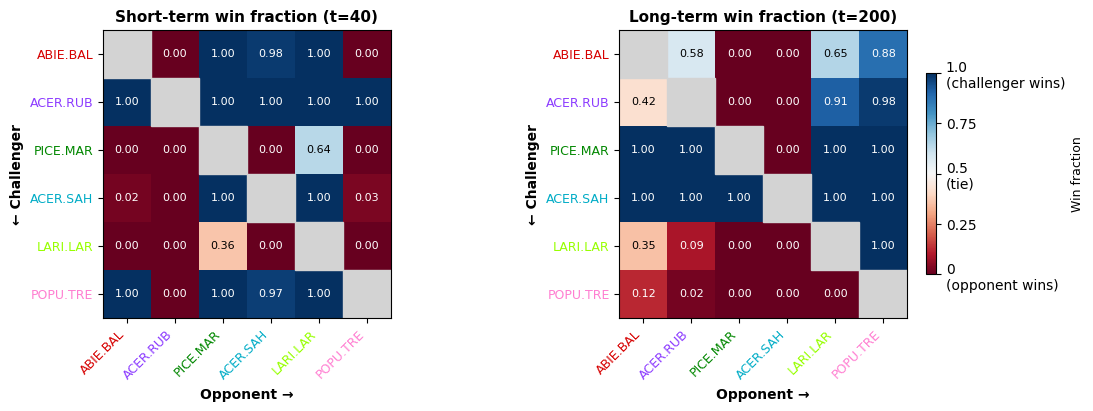

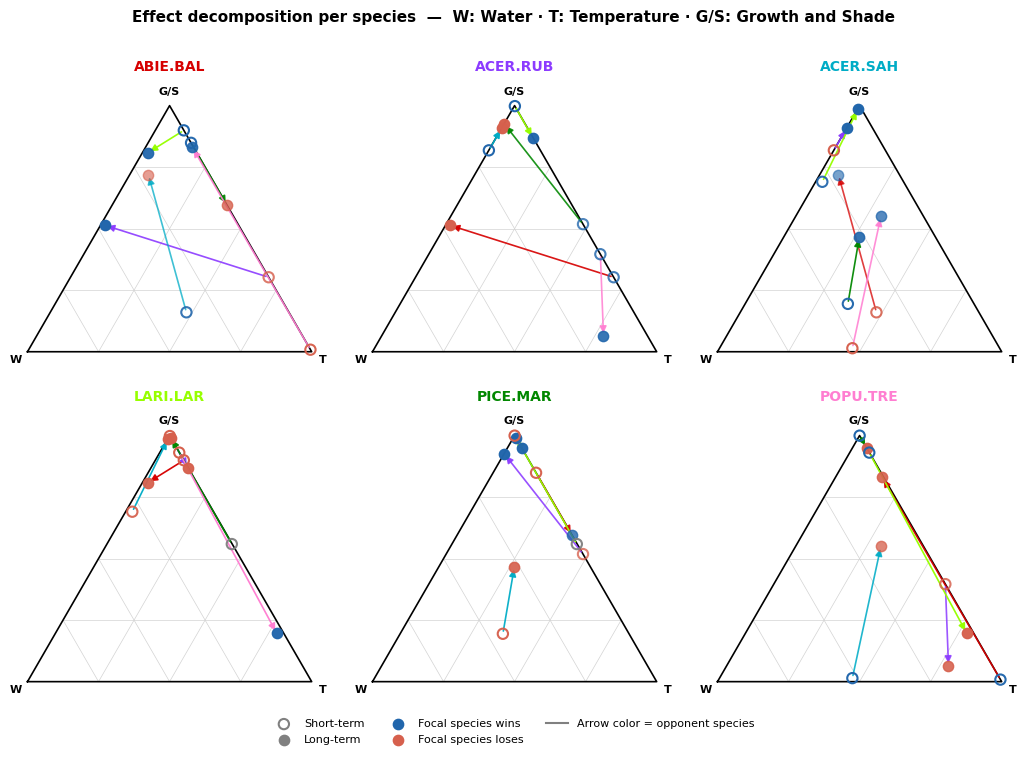

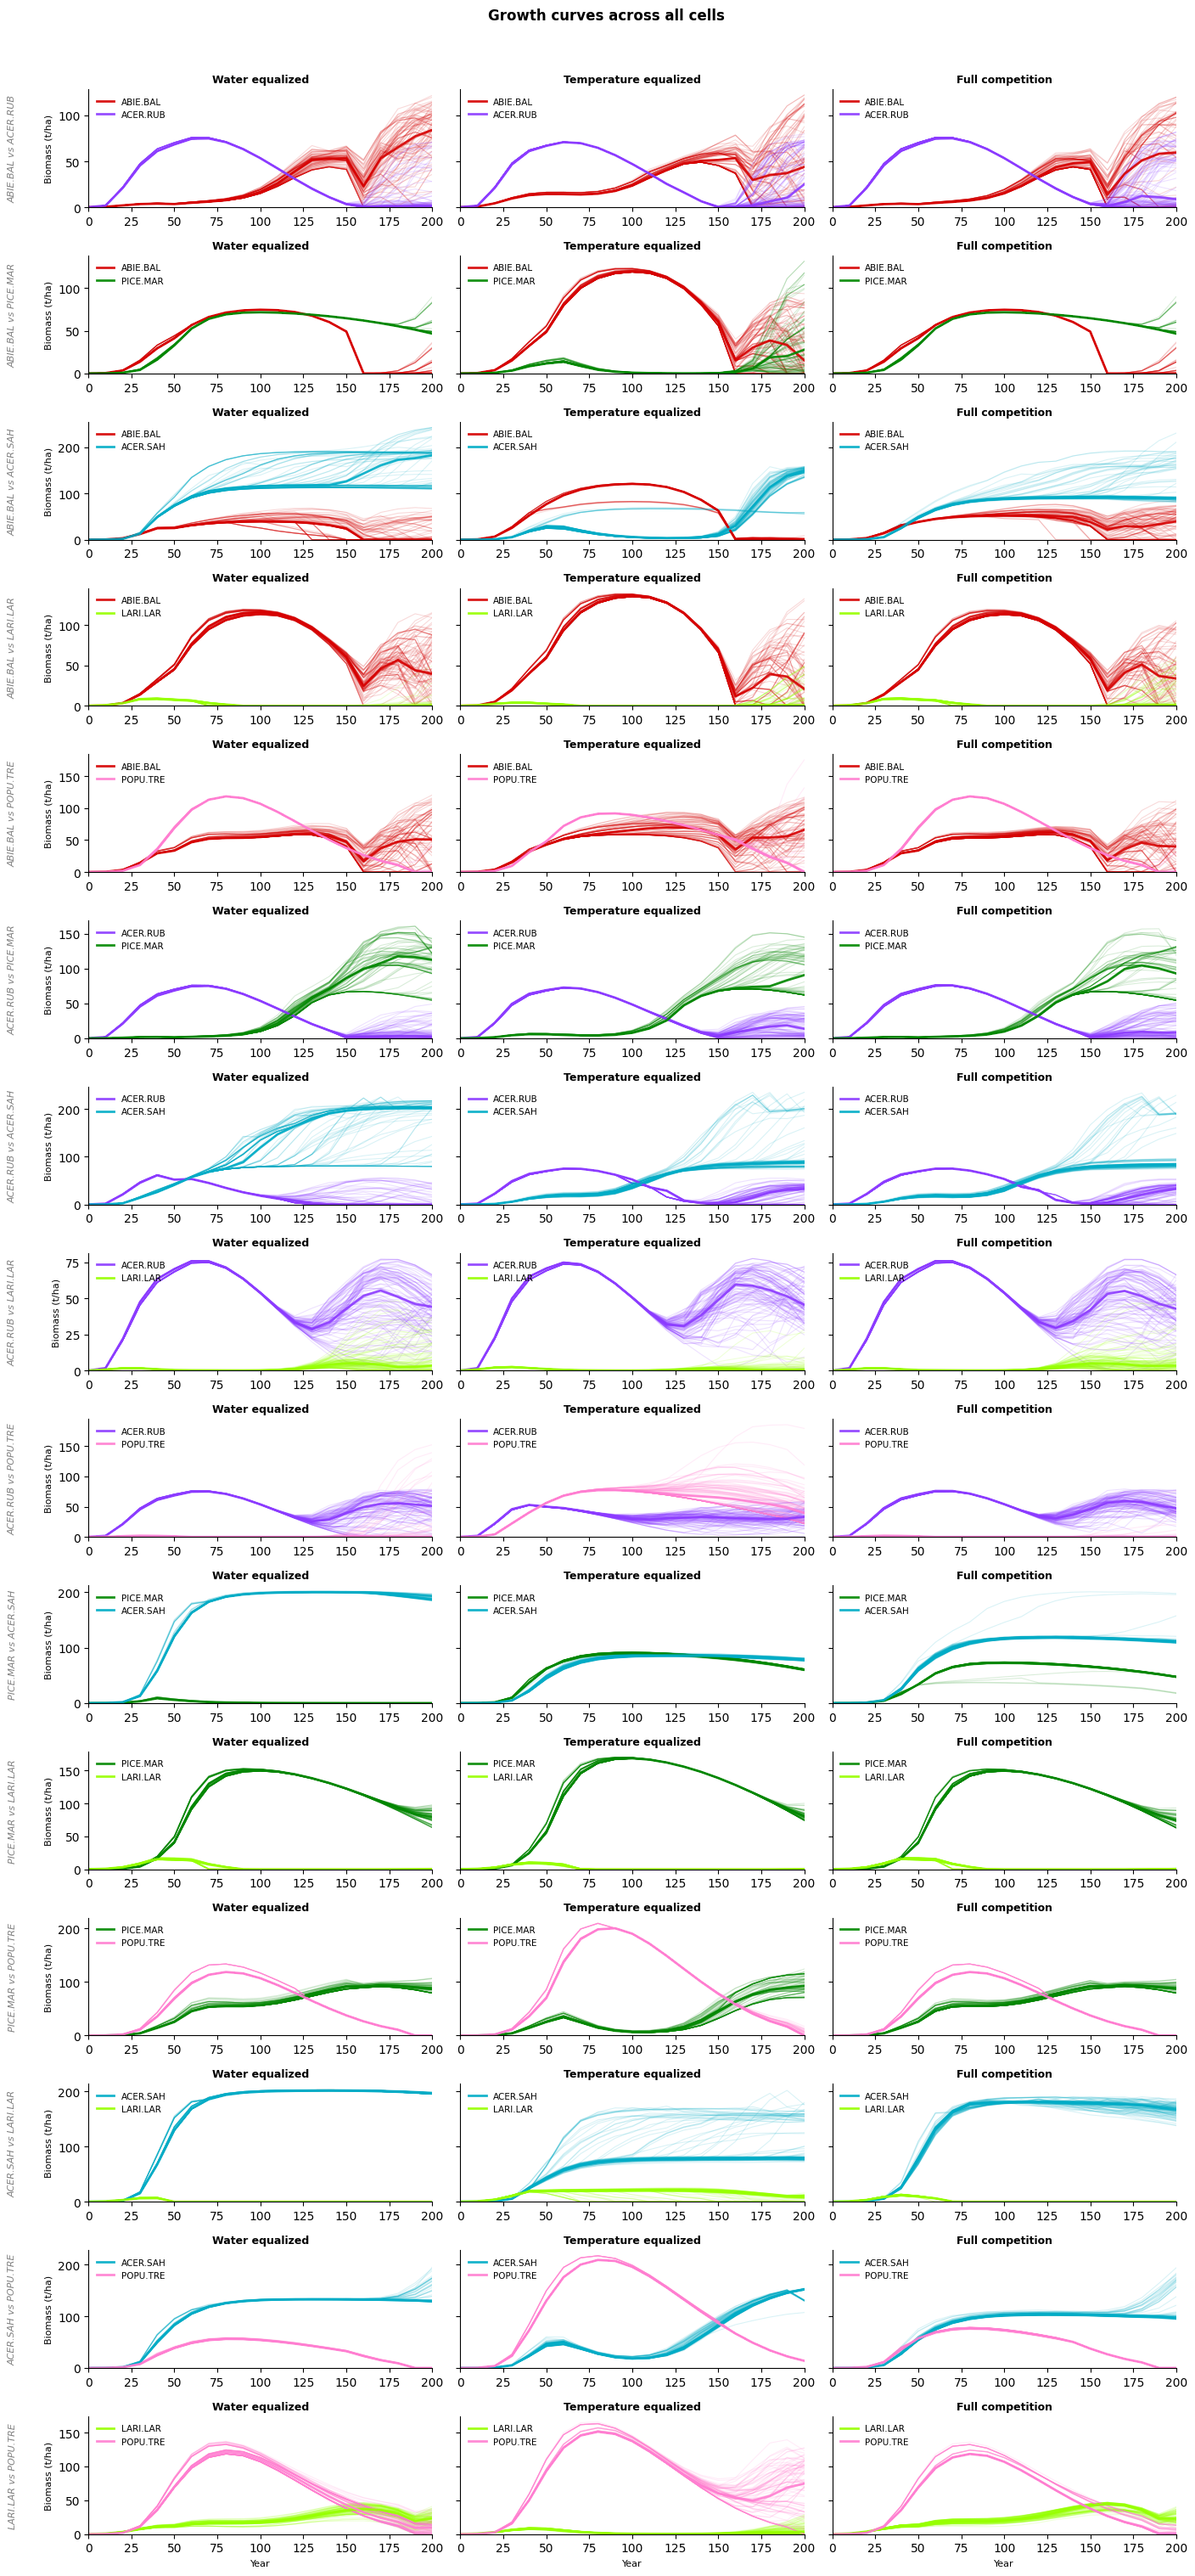

In [12]:
from functionsForCalibration import *

# Load the list of species using the species names dictionnary defined in Notebook 3.
with open('./SpeciesParametersSets/speciesNamesDictionnary.json', 'r') as file: speciesDict = json.load(file)

# ── 1. Run all simulations ─────────────────────────────────────────────────────
species_list = list(speciesDict.keys())  # your list

 # Use more workers (n_workers) to launch sims in parallel to speed up things
all_pairs = run_all_pairs(species_list, n_workers = 4,
                          dict_core_species = json.load(open('./SpeciesParametersSets/Calibrated_CompetitionTweaks/coreSpeciesParameters.json')),
                          dict_pnet_species = json.load(open('./SpeciesParametersSets/Calibrated_CompetitionTweaks/PnETSpeciesParameters.json')),
                          dict_pnet_generic= json.load(open('./SpeciesParametersSets/Calibrated_CompetitionTweaks/genericParameters.json')),
                         climate = "mild",
                         soil = "CLAY")

# ── 2. Compute effect decompositions ──────────────────────────────────────────
decomps_short, decomps_long = [], []
for pair in all_pairs:
    d_short, d_long = compute_effects(pair)
    decomps_short.append(d_short)
    decomps_long.append(d_long)

# ── 3. Plots ───────────────────────────────────────────────────────────────────
speciesColorDict = make_species_colors(species_list)

fig_matrices = plot_win_matrices(all_pairs, species_list, speciesColorDict)
fig_ternary  = plot_ternary_effects(decomps_short, decomps_long, speciesColorDict)
fig_curves   = plot_growth_curves_competition(all_pairs, speciesColorDict)

We see that as a result of our modifications,

- `ACER.SAH` is less competitive on the short term, which is what we expected.

I'll consider these results acceptable for now, and will keep going.